In [142]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [143]:
# Configurações do problema
r = 0.005      # Taxa de resfriamento [s⁻¹]
Tamb = 25      # Temperatura ambiente [°C]
T0 = 100       # Temperatura inicial [°C]
np.random.seed(42)  # Reprodutibilidade


In [144]:
# --- Dados sintéticos com ruído (0 a 300s) ---
np.random.seed(42)
t_train = np.linspace(0, 300, 10).reshape(-1, 1)
T_train = analytical_solution(t_train)
noise = np.random.normal(0, 0.5, size=T_train.shape)
T_noisy = T_train + noise

In [145]:
# --- Normalização ---
t_train_scaled = t_train / 1000.0  # entre 0 e 0.3
t_train_scaled = t_train_scaled.reshape(-1, 1)
T_noisy = T_noisy.reshape(-1, 1)

In [146]:
# --- Rede neural mais robusta ---
model = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(50, activation='tanh'),
    layers.Dense(50, activation='tanh'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(t_train_scaled, T_noisy, epochs=3000, verbose=0)

In [147]:
# --- Predição até 1000s ---
t_test = np.linspace(0, 1000, 1000)
t_test_scaled = t_test / 1000.0
T_pred = model.predict(t_test_scaled)
T_train[0] = T0  # Garante T(0) exato


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [148]:
# --- Solução analítica completa ---
T_exact = analytical_solution(t_test)

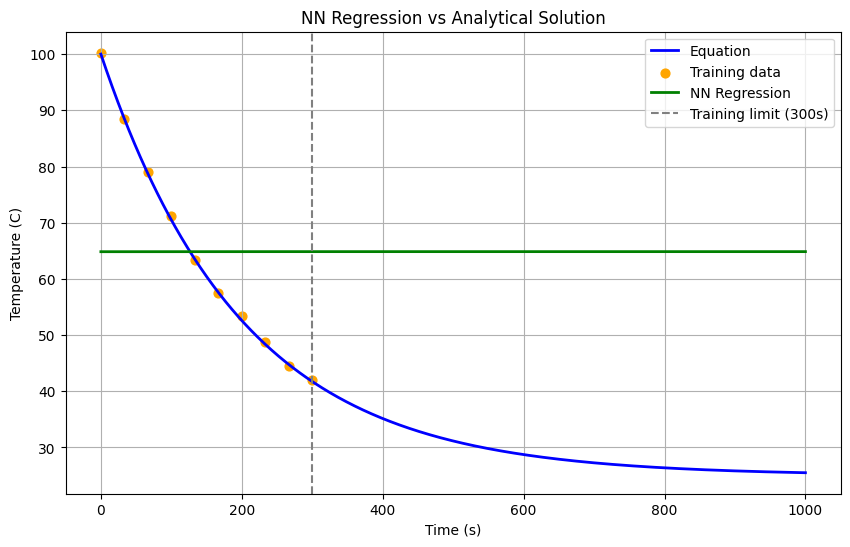

In [149]:
# --- Gráfico ---
plt.figure(figsize=(10, 6))
plt.plot(t_test, T_exact, label='Equation', color='blue', linewidth=2)
plt.scatter(t_train, T_noisy, label='Training data', color='orange', s=40)
plt.plot(t_test, T_pred, label='NN Regression', color='green', linewidth=2)
plt.axvline(x=300, color='gray', linestyle='--', label='Training limit (300s)')

plt.xlabel('Time (s)')
plt.ylabel('Temperature (C)')
plt.title('NN Regression vs Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()
# etapa 4 